# S4_2 — Masking Strategy Design and Visualisation

**Leaf-JEPA IRP** | Stage 4 — Leaf JEPA Pretraining

Demonstrates both masking approaches:
1. **Standard multi-block masking** — I-JEPA original (ablation baseline)
2. **Disease-region-biased masking** — novel contribution (hue-saliency weighted)

Produces dissertation-ready figures for Chapter 3 (Methodology).


## Imports

In [4]:
import sys
from pathlib import Path
from PIL import Image

import numpy as np
import torch
import pandas as pd

import matplotlib.pyplot as plt


PROJECT_ROOT = Path("..").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from stage4_leaf_jepa_pretraining.config_stage4 import *
from stage4_leaf_jepa_pretraining.pretrain_utils import (
    set_seed, PlantVillagePretrainDataset, get_pretrain_transform,
    MultiBlockMasking, DiseaseRegionBiasedMasking, SaliencyMap
)

from stage2_dataset_preparation.outputs.augmentation.transforms import (
    get_pretrain_transform, get_eval_transform, get_finetune_transform
)

set_seed(RANDOM_SEED)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("S4_2 Masking Strategy & Visualisation")


S4_2 Masking Strategy & Visualisation


## Calculating HUE

In [5]:
"""
Healthy Hue Centre Calibration
================================
Add this as a new cell in S4_2_masking_strategy.ipynb, right after Cell 3
(after masking strategies are initialised).

Computes the correct HEALTHY_HUE_CENTER and HEALTHY_HUE_SIGMA values
from actual PlantVillage 'healthy' class images — replacing the placeholder
0.30 / 0.10 defaults in config_stage4.py.

Run once, then copy the printed values into config_stage4.py.
"""

# ── Step 1: Find all healthy class images in training split ───────────────────
df = pd.read_csv(SPLITS_DIR / "plantvillage_splits.csv")
train_df = df[df["split"] == "train"].reset_index(drop=True)

# Identify healthy classes — PlantVillage names all contain 'healthy'
healthy_mask = train_df["class_name"].str.lower().str.contains("healthy")
healthy_df   = train_df[healthy_mask].reset_index(drop=True)

print(f"Total training images:         {len(train_df):,}")
print(f"Healthy class images (train):  {len(healthy_df):,}")
print(f"\nHealthy classes found:")
for cls in sorted(healthy_df["class_name"].unique()):
    n = (healthy_df["class_name"] == cls).sum()
    print(f"  {cls:<45} {n:>5} images")

# ── Step 2: Sample images and compute per-patch hue ───────────────────────────
# Use raw PIL images (no normalisation) for accurate colour measurement
N_SAMPLE      = min(2000, len(healthy_df))   # 200 images is enough for stable estimate
PATCH_SIZE_CAL = PATCH_SIZE                  # 14 for ViT-H/14
RESIZE_TO      = IMAGE_CROP                  # 224

from torchvision import transforms
raw_transform = transforms.Compose([
    transforms.Resize(IMAGE_RESIZE, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(RESIZE_TO),
    transforms.ToTensor(),   # → [0, 1] float, no normalisation
])

H_grid = W_grid = RESIZE_TO // PATCH_SIZE_CAL   # 16 x 16 grid

sampled_df = healthy_df.sample(N_SAMPLE, random_state=42).reset_index(drop=True)

all_patch_hues = []      # per-patch mean hue, all images
per_image_hues = []      # per-image mean hue (for sigma estimation)

for i, row in sampled_df.iterrows():
    try:
        img = Image.open(row["filepath"]).convert("RGB")
        img_t = raw_transform(img)   # (3, 224, 224), [0,1]
        R, G, B = img_t[0], img_t[1], img_t[2]

        # ── HSV Hue (vectorised) ──
        Cmax = torch.max(torch.stack([R, G, B], dim=0), dim=0).values
        Cmin = torch.min(torch.stack([R, G, B], dim=0), dim=0).values
        delta = Cmax - Cmin + 1e-8

        hue = torch.zeros_like(R)
        mask_r = (Cmax == R) & (delta > 1e-7)
        mask_g = (Cmax == G) & (delta > 1e-7)
        mask_b = (Cmax == B) & (delta > 1e-7)
        hue[mask_r] = ((G - B)[mask_r] / delta[mask_r]) % 6
        hue[mask_g] = ((B - R)[mask_g] / delta[mask_g]) + 2
        hue[mask_b] = ((R - G)[mask_b] / delta[mask_b]) + 4
        hue = (hue / 6.0).clamp(0, 1)   # normalise to [0, 1]

        # ── Per-patch mean hue (pool over patch windows) ──
        hue_patches = hue.unfold(0, PATCH_SIZE_CAL, PATCH_SIZE_CAL) \
            .unfold(1, PATCH_SIZE_CAL, PATCH_SIZE_CAL)  # (H_grid, W_grid, ps, ps)
        hue_mean = hue_patches.reshape(H_grid, W_grid, -1).mean(dim=-1)  # (H_grid, W_grid)

        # ── Exclude very-low-saturation patches (background / near-white) ──
        # Low saturation = grey/white background — these have unreliable hue
        sat = (Cmax - Cmin) / (Cmax + 1e-8)
        sat_patches = sat.unfold(0, PATCH_SIZE_CAL, PATCH_SIZE_CAL) \
            .unfold(1, PATCH_SIZE_CAL, PATCH_SIZE_CAL)
        sat_mean = sat_patches.reshape(H_grid, W_grid, -1).mean(dim=-1)

        # Only use patches with meaningful saturation (actual leaf, not background)
        leaf_mask = sat_mean > 0.10   # threshold: >10% saturation
        if leaf_mask.sum() > 0:
            patch_hues = hue_mean[leaf_mask].numpy()
            all_patch_hues.extend(patch_hues.tolist())
            per_image_hues.append(patch_hues.mean())

    except Exception as e:
        print(f"  Warning: could not process {row['filepath']}: {e}")
        continue

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{N_SAMPLE} images...")

print(f"\nTotal leaf patches analysed: {len(all_patch_hues):,}")

# ── Step 3: Compute statistics ────────────────────────────────────────────────
all_hues = np.array(all_patch_hues)
img_hues  = np.array(per_image_hues)

hue_mean_val   = float(np.mean(all_hues))
hue_median_val = float(np.median(all_hues))
hue_std_val    = float(np.std(all_hues))
hue_p5         = float(np.percentile(all_hues, 5))
hue_p95        = float(np.percentile(all_hues, 95))

# Recommended sigma: half the inter-quartile range
hue_iqr  = float(np.percentile(all_hues, 75) - np.percentile(all_hues, 25))
hue_sigma_rec = max(0.05, round(hue_iqr / 2, 3))   # floor at 0.05

print("\n" + "="*55)
print("  HEALTHY HUE CALIBRATION RESULTS")
print("="*55)
print(f"  Mean hue:       {hue_mean_val:.4f}  (HSV [0,1] space)")
print(f"  Median hue:     {hue_median_val:.4f}")
print(f"  Std dev:        {hue_std_val:.4f}")
print(f"  5th–95th pct:   {hue_p5:.4f} – {hue_p95:.4f}")
print(f"  IQR/2 (sigma):  {hue_sigma_rec:.4f}")
print()
print(f"  ✅ Recommended values for config_stage4.py:")
print(f"     HEALTHY_HUE_CENTER = {hue_median_val:.4f}   # median more robust than mean")
print(f"     HEALTHY_HUE_SIGMA  = {hue_sigma_rec:.4f}   # half-IQR of leaf patch hues")
print("="*55)

# ── Step 4: Hue distribution plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all patch hues
axes[0].hist(all_hues, bins=60, color="#4CAF50", alpha=0.7, edgecolor="white", linewidth=0.5)
axes[0].axvline(hue_median_val, color="#1565C0", linewidth=2, label=f"Median: {hue_median_val:.4f}")
axes[0].axvline(hue_mean_val,   color="#C62828", linewidth=2, linestyle="--", label=f"Mean:   {hue_mean_val:.4f}")
axes[0].axvspan(hue_median_val - hue_sigma_rec,
                hue_median_val + hue_sigma_rec,
                alpha=0.15, color="#1565C0", label=f"±sigma ({hue_sigma_rec:.3f})")
axes[0].set_xlabel("Hue value (HSV normalised [0, 1])", fontsize=11)
axes[0].set_ylabel("Patch count", fontsize=11)
axes[0].set_title("Healthy leaf patch hue distribution\n(all leaf patches, background excluded)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Hue colour reference bar at bottom
ax_bar = axes[0].inset_axes([0, -0.18, 1, 0.08])
hue_range = np.linspace(0, 1, 256)
# Show as HSV→RGB strip
hsv_strip = np.ones((1, 256, 3))
hsv_strip[0, :, 0] = hue_range
import matplotlib.colors as mcolors
rgb_strip = mcolors.hsv_to_rgb(hsv_strip)
ax_bar.imshow(rgb_strip, aspect="auto", extent=[0, 1, 0, 1])
ax_bar.set_xlim(0, 1); ax_bar.set_yticks([])
ax_bar.set_xlabel("Hue (HSV reference)", fontsize=9)

# Per-image mean hue scatter
axes[1].hist(img_hues, bins=40, color="#FF9800", alpha=0.7, edgecolor="white", linewidth=0.5)
axes[1].axvline(float(np.median(img_hues)), color="#1565C0", linewidth=2,
                label=f"Median: {np.median(img_hues):.4f}")
axes[1].set_xlabel("Per-image mean hue (HSV [0, 1])", fontsize=11)
axes[1].set_ylabel("Image count", fontsize=11)
axes[1].set_title(f"Per-image mean hue distribution\n({N_SAMPLE} sampled healthy images)", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle("PlantVillage Healthy Leaf Hue Calibration", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "healthy_hue_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Plot saved → healthy_hue_calibration.png")

# ── Step 5: Per-crop breakdown ────────────────────────────────────────────────
print("\nPer-crop healthy hue breakdown:")
print(f"  {'Class':<45} {'Mean hue':>10} {'Median':>10} {'Std':>8} {'N patches':>10}")
print("  " + "-"*85)

crop_stats = {}
for cls in sorted(healthy_df["class_name"].unique()):
    cls_rows = sampled_df[sampled_df["class_name"] == cls]
    if len(cls_rows) == 0:
        continue
    crop_hues = []
    for _, row in cls_rows.iterrows():
        try:
            img   = Image.open(row["filepath"]).convert("RGB")
            img_t = raw_transform(img)
            R, G, B = img_t[0], img_t[1], img_t[2]
            Cmax  = torch.max(torch.stack([R,G,B]),dim=0).values
            Cmin  = torch.min(torch.stack([R,G,B]),dim=0).values
            delta = Cmax - Cmin + 1e-8
            hue   = torch.zeros_like(R)
            mr, mg, mb = (Cmax==R)&(delta>1e-7),(Cmax==G)&(delta>1e-7),(Cmax==B)&(delta>1e-7)
            hue[mr] = ((G-B)[mr]/delta[mr]) % 6
            hue[mg] = ((B-R)[mg]/delta[mg]) + 2
            hue[mb] = ((R-G)[mb]/delta[mb]) + 4
            hue     = (hue/6.0).clamp(0,1)
            sat     = (Cmax-Cmin)/(Cmax+1e-8)
            sat_p   = sat.unfold(0,PATCH_SIZE_CAL,PATCH_SIZE_CAL).unfold(1,PATCH_SIZE_CAL,PATCH_SIZE_CAL)
            hue_p   = hue.unfold(0,PATCH_SIZE_CAL,PATCH_SIZE_CAL).unfold(1,PATCH_SIZE_CAL,PATCH_SIZE_CAL)
            sat_m   = sat_p.reshape(H_grid,W_grid,-1).mean(-1)
            hue_m   = hue_p.reshape(H_grid,W_grid,-1).mean(-1)
            leaf    = sat_m > 0.10
            if leaf.sum() > 0:
                crop_hues.extend(hue_m[leaf].numpy().tolist())
        except: pass

    if crop_hues:
        ch = np.array(crop_hues)
        crop_stats[cls] = ch
        print(f"  {cls:<45} {ch.mean():>10.4f} {np.median(ch):>10.4f} {ch.std():>8.4f} {len(ch):>10,}")

# ── Step 6: Final recommended config update ───────────────────────────────────
print("\n" + "="*55)
print("  COPY INTO config_stage4.py")
print("="*55)
print(f"  HEALTHY_HUE_CENTER = {hue_median_val:.4f}")
print(f"  HEALTHY_HUE_SIGMA  = {hue_sigma_rec:.4f}")
print()
print("  Also update pretrain_utils.py SaliencyMap defaults:")
print(f"  SaliencyMap(healthy_hue_center={hue_median_val:.4f},")
print(f"              healthy_hue_sigma= {hue_sigma_rec:.4f})")
print("="*55)

Total training images:         38,013
Healthy class images (train):  10,559

Healthy classes found:
  ['Apple___healthy']                            1152 images
  ['Blueberry___healthy']                        1051 images
  ['Cherry_(including_sour)___healthy']           598 images
  ['Corn_(maize)___healthy']                      813 images
  ['Grape___healthy']                             296 images
  ['Peach___healthy']                             252 images
  ['Pepper,_bell___healthy']                     1035 images
  ['Potato___healthy']                            106 images
  ['Raspberry___healthy']                         260 images
  ['Soybean___healthy']                          3563 images
  ['Strawberry___healthy']                        319 images
  ['Tomato___healthy']                           1114 images
  Processed 100/2000 images...
  Processed 200/2000 images...
  Processed 300/2000 images...
  Processed 400/2000 images...
  Processed 500/2000 images...
  Processed 6

## Load Samples

In [7]:
transform = get_pretrain_transform()
csv_path  = SPLITS_DIR / "plantvillage_splits.csv"
dataset   = PlantVillagePretrainDataset(csv_path, transform=transform)

# Sample diverse images (diseased and healthy)
sample_indices = [i for i in range(0, min(len(dataset), 10000), 600)][:8]
sample_imgs    = torch.stack([dataset[i][0] for i in sample_indices])
print(f"Sample images loaded: {sample_imgs.shape}")


  PlantVillagePretrainDataset: 38,013 training images
Sample images loaded: torch.Size([8, 3, 224, 224])


Sample class distribution:
  [0] ['Apple___Cedar_apple_rust']
  [1] ['Tomato___Tomato_Yellow_Leaf_Curl_Virus']
  [2] ['Tomato___Tomato_Yellow_Leaf_Curl_Virus']
  [3] ['Soybean___healthy']
  [4] ['Tomato___Tomato_Yellow_Leaf_Curl_Virus']
  [5] ['Tomato___Bacterial_spot']
  [6] ['Orange___Haunglongbing_(Citrus_greening)']
  [7] ['Strawberry___healthy']


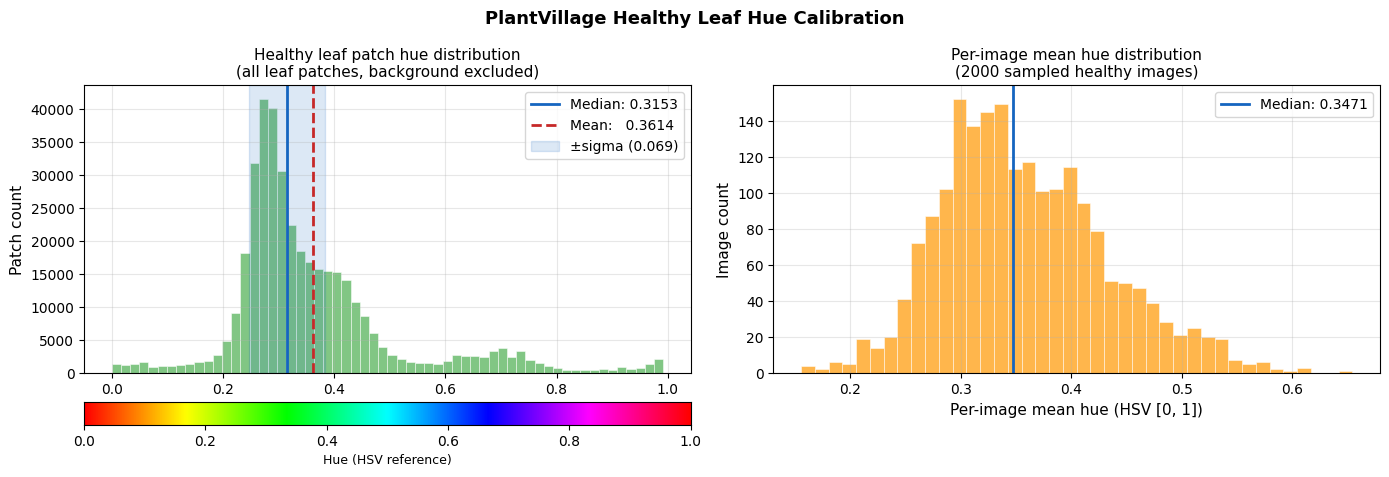

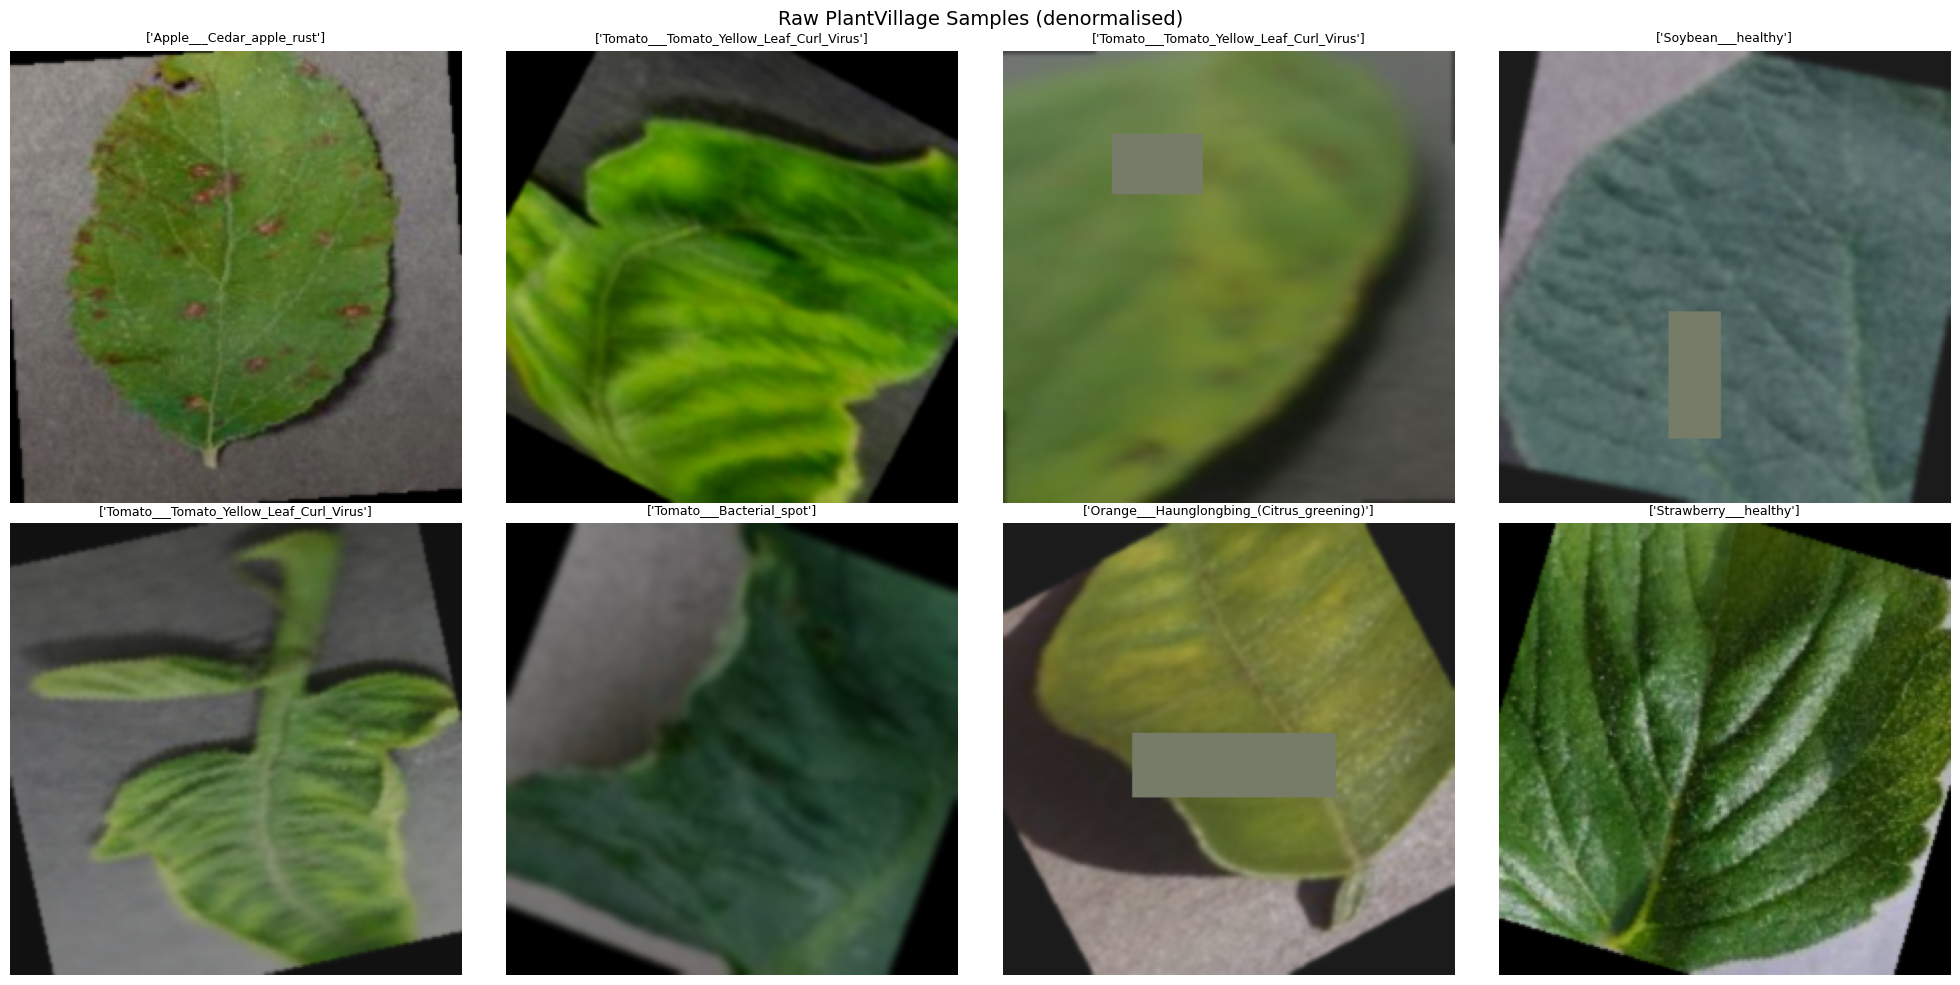

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

import torch

mean = torch.tensor(NORM_MEAN).view(3,1,1)
std  = torch.tensor(NORM_STD).view(3,1,1)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, img_t in enumerate(sample_imgs):
    img_vis = (img_t * std + mean).clamp(0,1)
    img_np  = img_vis.permute(1,2,0).numpy()
    axes[i].imshow(img_np)
    # Show class name if available
    label_idx = dataset.df.iloc[sample_indices[i]]["label_idx"]
    class_name = dataset.df.iloc[sample_indices[i]].get(
        "class_name", f"Class {label_idx}"
    )
    axes[i].set_title(class_name, fontsize=9)
    axes[i].axis("off")

plt.suptitle("Raw PlantVillage Samples (denormalised)", fontsize=14)
plt.tight_layout()
# plt.show()
print("Sample class distribution:")
for i, img_t in enumerate(sample_imgs):
    cn = dataset.df.iloc[sample_indices[i]].get("class_name","?")
    print(f"  [{i}] {cn}")

## Initializing Masking startergies

In [9]:
# Standard masking (I-JEPA original)
standard_masking = MultiBlockMasking(
    image_size        = IMAGE_CROP,
    patch_size        = PATCH_SIZE,
    num_target_blocks = PT_NUM_TARGET_BLOCKS,
    context_scale     = PT_CONTEXT_SCALE,
    context_ratio     = PT_CONTEXT_RATIO,
    target_scale      = PT_TARGET_SCALE,
    target_ratio      = PT_TARGET_RATIO,
)

# Disease-region-biased masking (novel contribution)
biased_masking = DiseaseRegionBiasedMasking(
    image_size        = IMAGE_CROP,
    patch_size        = PATCH_SIZE,
    num_target_blocks = PT_NUM_TARGET_BLOCKS,
    context_scale     = PT_CONTEXT_SCALE,
    context_ratio     = PT_CONTEXT_RATIO,
    target_scale      = PT_TARGET_SCALE,
    target_ratio      = PT_TARGET_RATIO,
    bias_strength     = SALIENCY_BIAS_STRENGTH,
)

# Saliency function
saliency_fn = SaliencyMap(
    patch_size         = PATCH_SIZE,
    image_size         = IMAGE_CROP,
    healthy_hue_center = HEALTHY_HUE_CENTER,
    healthy_hue_sigma  = HEALTHY_HUE_SIGMA,
)

print("✅ Masking strategies initialised")
print(f"  Standard: MultiBlockMasking, {PT_NUM_TARGET_BLOCKS} targets")
print(f"  Biased:   DiseaseRegionBiasedMasking, bias_strength={SALIENCY_BIAS_STRENGTH}")


✅ Masking strategies initialised
  Standard: MultiBlockMasking, 4 targets
  Biased:   DiseaseRegionBiasedMasking, bias_strength=3.0


## Visualize Masking

### Standard masking

In [10]:
fig, axes_grid = plt.subplots(8, 3, figsize=(15, 20))
for row_i, img_t in enumerate(sample_imgs[:8]):
    ctx_mask, tgt_masks = standard_masking()
    # Inline simple visualisation
    H = W = IMAGE_CROP // PATCH_SIZE
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std  = torch.tensor(NORM_STD).view(3, 1, 1)
    img_vis = (img_t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    overlay_ctx = img_vis.copy()
    for i in range(H * W):
        if not ctx_mask[i]:
            r, c = i // W, i % W
            overlay_ctx[r*PATCH_SIZE:(r+1)*PATCH_SIZE, c*PATCH_SIZE:(c+1)*PATCH_SIZE] *= 0.3

    import matplotlib.cm as cm
    colours = cm.Set1(np.linspace(0, 0.8, len(tgt_masks)))
    overlay_tgt = img_vis.copy() * 0.4
    for tm, col in zip(tgt_masks, colours):
        for i in range(H * W):
            if tm[i]:
                r, c = i // W, i % W
                overlay_tgt[r*PATCH_SIZE:(r+1)*PATCH_SIZE, c*PATCH_SIZE:(c+1)*PATCH_SIZE] =                     overlay_tgt[r*PATCH_SIZE:(r+1)*PATCH_SIZE, c*PATCH_SIZE:(c+1)*PATCH_SIZE] * 0.1 +                     np.array(col[:3]) * 0.9

    axes_grid[row_i, 0].imshow(img_vis)
    axes_grid[row_i, 0].set_title("Original" if row_i == 0 else "")
    axes_grid[row_i, 0].axis("off")
    axes_grid[row_i, 1].imshow(overlay_ctx)
    axes_grid[row_i, 1].set_title(f"Context ({ctx_mask.sum().item()} patches)" if row_i == 0 else "")
    axes_grid[row_i, 1].axis("off")
    axes_grid[row_i, 2].imshow(overlay_tgt)
    axes_grid[row_i, 2].set_title(f"Targets ({len(tgt_masks)} blocks)" if row_i == 0 else "")
    axes_grid[row_i, 2].axis("off")

fig.suptitle("Standard I-JEPA Multi-Block Masking (Ablation Baseline)", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"S4_standard_masking_examples.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ Standard masking figure saved")


✅ Standard masking figure saved


### Saliency maps

In [11]:
fig, axes = plt.subplots(8, 3, figsize=(15, 20))
for row_i, img_t in enumerate(sample_imgs[:8]):
    saliency = saliency_fn(img_t, NORM_MEAN, NORM_STD)
    H = W = IMAGE_CROP // PATCH_SIZE
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std  = torch.tensor(NORM_STD).view(3, 1, 1)
    img_vis = (img_t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    sal_map = saliency.reshape(H, W)
    sal_up  = np.repeat(np.repeat(sal_map, PATCH_SIZE, 0), PATCH_SIZE, 1)
    sal_norm= (sal_up - sal_up.min()) / (sal_up.max() - sal_up.min() + 1e-8)

    axes[row_i, 0].imshow(img_vis)
    axes[row_i, 0].axis("off")
    axes[row_i, 0].set_title("Image" if row_i == 0 else "")

    im = axes[row_i, 1].imshow(sal_map, cmap="hot", interpolation="nearest")
    axes[row_i, 1].axis("off")
    axes[row_i, 1].set_title("Hue-Deviation Saliency" if row_i == 0 else "")

    axes[row_i, 2].imshow(img_vis)
    axes[row_i, 2].imshow(sal_norm, cmap="Reds", alpha=0.45)
    axes[row_i, 2].axis("off")
    axes[row_i, 2].set_title("Overlay" if row_i == 0 else "")

fig.suptitle("Disease-Region Saliency Map\n(Hue deviation from healthy leaf distribution — Novel Contribution)", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"S4_saliency_examples_strength_{SALIENCY_BIAS_STRENGTH}.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ Saliency map figure saved")


✅ Saliency map figure saved


### Biased masking

In [12]:
fig, axes = plt.subplots(8, 3, figsize=(15, 20))
for row_i, img_t in enumerate(sample_imgs[:8]):
    saliency = saliency_fn(img_t, NORM_MEAN, NORM_STD)
    ctx_mask, tgt_masks = biased_masking(saliency=saliency)

    H = W = IMAGE_CROP // PATCH_SIZE
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std  = torch.tensor(NORM_STD).view(3, 1, 1)
    img_vis = (img_t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    overlay_ctx = img_vis.copy()
    for i in range(H * W):
        if not ctx_mask[i]:
            r, c = i // W, i % W
            overlay_ctx[r*PATCH_SIZE:(r+1)*PATCH_SIZE, c*PATCH_SIZE:(c+1)*PATCH_SIZE] *= 0.3

    import matplotlib.cm as cm
    colours = cm.Set1(np.linspace(0, 0.8, len(tgt_masks)))
    overlay_tgt = img_vis.copy() * 0.4
    for tm, col in zip(tgt_masks, colours):
        for i in range(H * W):
            if tm[i]:
                r, c = i // W, i % W
                overlay_tgt[r*PATCH_SIZE:(r+1)*PATCH_SIZE, c*PATCH_SIZE:(c+1)*PATCH_SIZE] =                     overlay_tgt[r*PATCH_SIZE:(r+1)*PATCH_SIZE, c*PATCH_SIZE:(c+1)*PATCH_SIZE] * 0.1 +                     np.array(col[:3]) * 0.9

    axes[row_i, 0].imshow(img_vis)
    axes[row_i, 0].axis("off")
    axes[row_i, 0].set_title("Image" if row_i == 0 else "")
    axes[row_i, 1].imshow(overlay_ctx)
    axes[row_i, 1].axis("off")
    axes[row_i, 1].set_title("Context (biased)" if row_i == 0 else "")
    axes[row_i, 2].imshow(overlay_tgt)
    axes[row_i, 2].axis("off")
    axes[row_i, 2].set_title("Targets (disease-biased)" if row_i == 0 else "")

fig.suptitle("Disease-Region-Biased I-JEPA Masking (Novel Contribution)\nTargets preferentially placed over disease lesion regions", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"S4_biased_masking_examples_{SALIENCY_BIAS_STRENGTH}.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("✅ Biased masking figure saved")
print("\nKey comparison for dissertation (Figure 3.x):")
print("  Left panel:  Standard masking → targets randomly distributed")
print("  Right panel: Biased masking   → targets cluster over lesion regions")


✅ Biased masking figure saved

Key comparison for dissertation (Figure 3.x):
  Left panel:  Standard masking → targets randomly distributed
  Right panel: Biased masking   → targets cluster over lesion regions


## Masking coverage stat

In [13]:
# Quantify masking coverage statistics
import numpy as np

print("Computing masking coverage statistics over 2000 random samples...")
set_seed(RANDOM_SEED)

std_coverage, biased_coverage = [], []
std_target_counts, biased_target_counts = [], []

for i in range(2000):
    img_t = sample_imgs[i % len(sample_imgs)]
    saliency = saliency_fn(img_t, NORM_MEAN, NORM_STD)

    ctx_std, tgt_std = standard_masking()
    ctx_bia, tgt_bia = biased_masking(saliency=saliency)

    total = ctx_std.shape[0]
    std_coverage.append(ctx_std.sum().item() / total)
    biased_coverage.append(ctx_bia.sum().item() / total)

    # Average saliency of target patches vs all patches
    tgt_std_sal = np.mean([saliency[tm.nonzero(as_tuple=False).squeeze(-1).numpy()].mean()
                            for tm in tgt_std if tm.sum() > 0])
    tgt_bia_sal = np.mean([saliency[tm.nonzero(as_tuple=False).squeeze(-1).numpy()].mean()
                            for tm in tgt_bia if tm.sum() > 0])
    std_target_counts.append(tgt_std_sal)
    biased_target_counts.append(tgt_bia_sal)

print(f"\nContext coverage (standard):  {np.mean(std_coverage)*100:.1f}% ± {np.std(std_coverage)*100:.1f}%")
print(f"Context coverage (biased):    {np.mean(biased_coverage)*100:.1f}% ± {np.std(biased_coverage)*100:.1f}%")
print(f"\nTarget avg saliency (standard): {np.mean(std_target_counts):.4f}")
print(f"Target avg saliency (biased):   {np.mean(biased_target_counts):.4f}")
ratio = np.mean(biased_target_counts) / (np.mean(std_target_counts) + 1e-8)
print(f"  Saliency ratio biased/standard: {ratio:.2f}x")
print(f"\n  → Biased masking selects {ratio:.1f}x more salient (disease-like) patches as targets")
print("  → This quantifies the contribution of the novel masking strategy")


Computing masking coverage statistics over 2000 random samples...

Context coverage (standard):  90.6% ± 4.6%
Context coverage (biased):    90.5% ± 4.6%

Target avg saliency (standard): 0.2301
Target avg saliency (biased):   0.2509
  Saliency ratio biased/standard: 1.09x

  → Biased masking selects 1.1x more salient (disease-like) patches as targets
  → This quantifies the contribution of the novel masking strategy
